# Assignment 3: Linear Models
Kaitlin Luu

### Q1

1. What makes a model "linear"? "Linear" in what?
A model is "linear" if it is linear in its parameters, meaning that the equation is the sum of the predictors. x can be transformed however, but for the model to stay linear, x must be multiplied by a coefficient and the products must be added together. 

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
For a dummy/one-hot-encoded variable, the coefficient is the difference in the average value of y between the reference category and the category that the dummy represents. To handle the intercept, we can drop one of the categories since the intercept is the baseline and the coefficient is the relative difference. 

3. Can linear regression be used for classification? Explain why, or why not.
Linear regression should not be used for classification because it will produce an unreliable model. Linear regression can only predict continuous variables and not binary variables. Additionally, it is very sensitive to outliers, which can skew a model and produce inaccurate classifications. 

4. What are signs that your linear model is over-fitting?
One sign that your linear model is over-fitting is that the error on the training data is very low, but the error on the testing data is very high. Another sign is abnormally large or small coefficients, which indicate that the model is using extreme values to cancel out noise. Overall, high variance is a sign of over-fitting because this shows that the model is following noise and does not perform well on unseen data.

5. Clearly explain multi-colinearity using the two-stage least squares technique.
2SLS involves an instrumental variable that is used to regress x in order to get a "clean" x that is able to better predict the outcome y. In a multi-colinearity scenario where 2SLS is used, the instrument variable is highly correlated with other independent variables in the model. Therefore, the clean version of x will reflect this, and the model will not be able to tell which variable is producing the effect because they will all be too similar.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable y and your features/control/response/independent variables x into your analysis?
You can incorporate nonlinear models by transforming the independent variable x. This can be done through raising x to a power, taking the log of x, or multiplying it by another independent variable.

7. What is the interpretation of the slope coefficient in a linear regression?
The slope coefficient is the average change in the dependent variable y for every one unit increase in the independent variable x.

8. Compare the train/test split and k-fold cross validation.
Train/test split and k-fold cross validation are both ways of estimating how well a model will perform on unseen (test) data. Train/test split involves splitting the original dataset into two groups. One group is used to train the model and the other group is used to test the model. k-fold cross validation involves training the model k times. For each time, a different fold is used as the test set and the remaining k - 1 fold is used as the training set. Then, you average the results of all k trials to get the final performance score. This makes it a more reliable method than train/test split, but it is also less efficient and should be used for smaller datasets.

9.  How is the k in k-fold cross validation typically selected?
k is typically selected based on the size of the dataset. The k cannot be too small because the model will not be trained on the entire dataset, leading to biased results. However, the k also cannot be too large because the model will become sensitive to noise, leading to high variance. Therefore, we use a smaller k for a larger dataset and a larger k for a smaller dataset.

### Q2

In [1]:
# 1

import pandas as pd
import numpy as np

nyc = pd.read_csv('./data/Q1_clean.csv')
nyc.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [2]:
nyc.columns = nyc.columns.str.strip()
nyc.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')

In [3]:
nyc.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


The most expensive bourough, on average, is Manhattan.

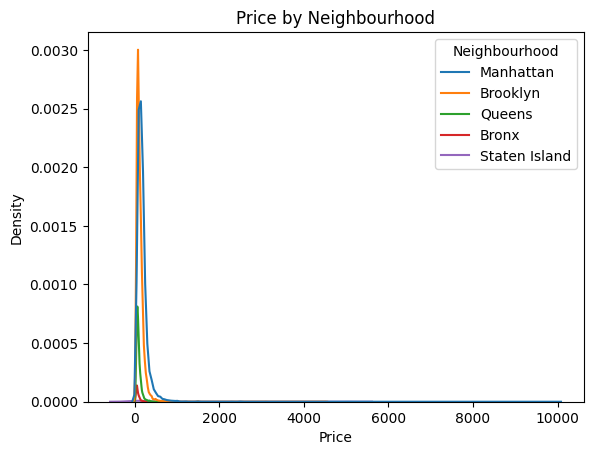

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=nyc, x='Price', hue='Neighbourhood')
plt.title('Price by Neighbourhood')
plt.show()

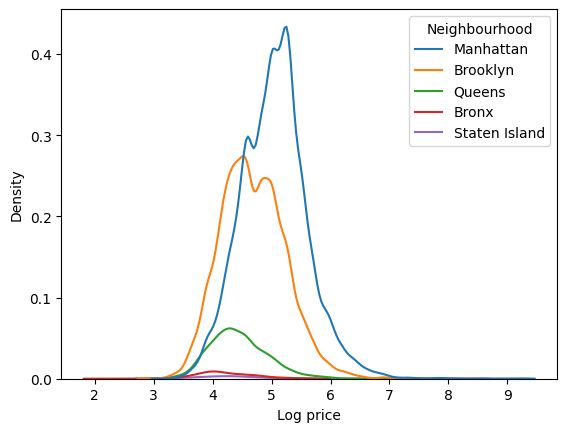

In [5]:
nyc['Log price'] = np.log(nyc['Price'])

sns.kdeplot(data=nyc, x='Log price', hue='Neighbourhood')
plt.show()


In [6]:
# 2

from sklearn.linear_model import LinearRegression

X = pd.get_dummies(nyc['Neighbourhood'], drop_first=True)
y = nyc['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Intercept: 75.27649769584607
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


Here, I dropped the first category, which was the Bronx. This means that the intercept equals the average price in the Bronx and each coefficient is the different between that borough's mean price and the Bronx's mean price. Therefore, the estimated regression coefficients correspond directly to the differences between the conditional group means from the table in Part 1.

In [7]:
# 3

X = nyc[['Review Scores Rating']]
y = nyc['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 60.87839065712386
Slope: 1.020826602267473


The slope coefficient being 1.02 means that for each one point increase in the review score rating, the predicted price per night increases by 1.02, on average.

In [8]:
# 4

dummies = pd.get_dummies(nyc['Neighbourhood'], drop_first=True)

X = pd.concat([nyc[['Review Scores Rating']], dummies], axis=1)
y = nyc['Price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])
coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Intercept: -23.81256101167304
Slope: 1.0811164834598521
Review Scores Rating      1.081116
Brooklyn                 51.704240
Manhattan               108.228737
Queens                   21.694600
Staten Island            71.766552
dtype: float64


The slope for the price regression on both Neighbourhood and Review Scores Rating is slightly steeper, at 1.08 as opposed to 1.02. This indicates that neighbourhood is an effective indicator in predicting price. 

The neighbourhood averages are pretty similar to the price regression on just Neighbourhood, only having roughly one point differences.

In [9]:
# 5

dummies = pd.get_dummies(nyc['Neighbourhood'], drop_first=True)

interactions = dummies.mul(nyc['Review Scores Rating'], axis=0)
interactions.columns = [col + '_interaction' for col in dummies.columns]

X = pd.concat([nyc[['Review Scores Rating']], dummies, interactions], axis=1)
y = nyc['Price']

model = LinearRegression()
model.fit(X, y)

coef_table = pd.Series(model.coef_, index=X.columns)
print(coef_table)

Review Scores Rating            0.574311
Brooklyn                      -16.392990
Manhattan                      41.315429
Queens                         28.259701
Staten Island                2963.071040
Brooklyn_interaction            0.741165
Manhattan_interaction           0.729703
Queens_interaction             -0.072294
Staten Island_interaction     -31.831748
dtype: float64


In [10]:
base_slope = coef_table['Review Scores Rating']

slopes = {}
slopes['Bronx'] = base_slope

for col in dummies.columns:
    slopes[col] = base_slope + coef_table[col + '_interaction']

for k, v in slopes.items():
    print(f"{k}: {v}")

Bronx: 0.5743109493638973
Brooklyn: 1.3154762151087427
Manhattan: 1.304014393927317
Queens: 0.5020166039976407
Staten Island: -31.257436624712614


Overall, the slopes across neighbourhoods are not very similar. However, the Bronx and Queens have similar slopes, and Brooklyn and Manhattan have similar slopes. Staten Island has an extreme negative slope, compared to the others. 

In [11]:
# 6

from sklearn.model_selection import cross_val_score

X1 = nyc[['Review Scores Rating']]
y = nyc['Price']

model = LinearRegression()

cv1 = cross_val_score(model, X1, y, cv=5, scoring='neg_mean_squared_error')
print("Model 1 MSE:", -np.mean(cv1))

Model 1 MSE: 22102.830156262135


In [12]:
dummies = pd.get_dummies(nyc['Neighbourhood'], drop_first=True)

X2 = pd.concat([nyc[['Review Scores Rating']], dummies], axis=1)

cv2 = cross_val_score(model, X2, y, cv=5, scoring='neg_mean_squared_error')
print("Model 2 MSE:", -np.mean(cv2))

Model 2 MSE: 21113.1124222621


In [13]:
interactions = dummies.mul(nyc['Review Scores Rating'], axis=0)
interactions.columns = [col + '_interaction' for col in dummies.columns]

X3 = pd.concat([nyc[['Review Scores Rating']], dummies, interactions], axis=1)

cv3 = cross_val_score(model, X3, y, cv=5, scoring='neg_mean_squared_error')
print("Model 3 MSE:", -np.mean(cv3))

Model 3 MSE: 21418.24687045032


### Q3

In [14]:
# 1

cars = pd.read_csv('data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [15]:
cars['Price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

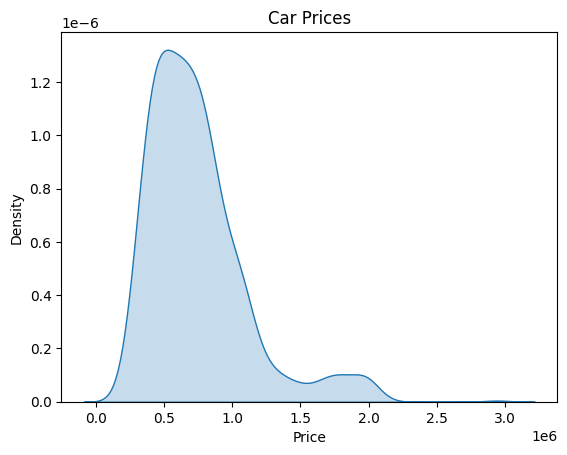

In [16]:
sns.kdeplot(cars["Price"], fill=True)
plt.title("Car Prices")
plt.show()

In [17]:
cars.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


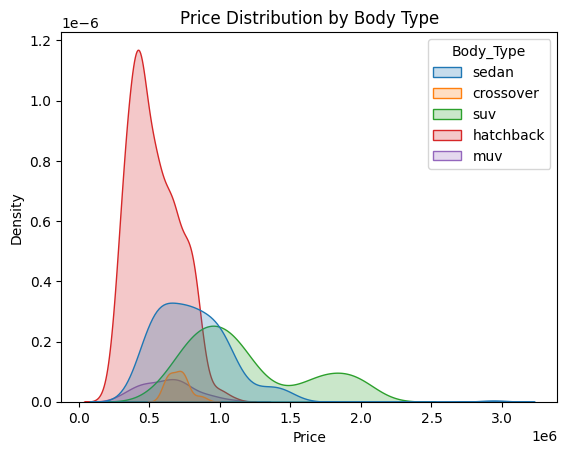

In [18]:
sns.kdeplot(data=cars, x="Price", hue="Body_Type", fill=True)
plt.title("Price Distribution by Body Type")
plt.show()

SUVs are the most expensive car type, and they also have the most variance.

In [19]:
# 2

X = cars[['Seating_Capacity']]
y = cars['Price']

model = LinearRegression()
model.fit(X, y)

print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

Slope: 59267.9980367217
Intercept: 439032.0141018268


The slope is 59268, meaning that for every additional seat in a car, the price increases by 59268.

In [20]:
X_cat = pd.get_dummies(cars['Seating_Capacity'], drop_first=True)

model_cat = LinearRegression()
model_cat.fit(X_cat, y)

coef_table = pd.Series(model_cat.coef_, index=X_cat.columns)
print(coef_table)

5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64


No, the differences in price are not linear in the number of seats because the price jumps up and down with each additional seat. It is not just a consistent increase.

In [21]:
# 3

from sklearn.preprocessing import PolynomialFeatures

cars['Age'] = 2026 - cars['Make_Year']

X = cars[['Age']]
y = cars['Price']

degrees = range(1, 8)
cv_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()

    scores = cross_val_score(model, X_poly, y, cv=10, scoring='neg_mean_squared_error')

    mse = -scores.mean()
    cv_errors.append(mse)

for d, err in zip(degrees, cv_errors):
    print(f"Degree {d} MSE = {err}")

Degree 1 MSE = 100295370079.45541
Degree 2 MSE = 100814620596.42152
Degree 3 MSE = 100380163091.91893
Degree 4 MSE = 100474431121.09737
Degree 5 MSE = 100131346195.8412
Degree 6 MSE = 100347765617.4783
Degree 7 MSE = 99809278371.8249


In [22]:
best_degree = degrees[np.argmin(cv_errors)]
print('Optimal degree:', best_degree)

Optimal degree: 7


C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


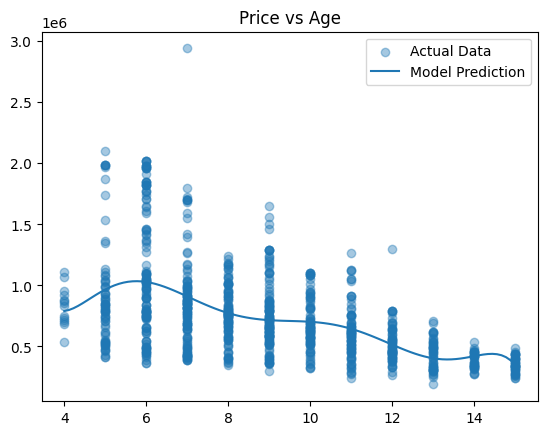

In [23]:
# 4

X = cars[['Age']]
y = cars['Price']

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

age_grid = np.linspace(cars['Age'].min(), cars['Age'].max(), 100).reshape(-1, 1)
age_grid_poly = poly.transform(age_grid)

y_pred = model.predict(age_grid_poly)

plt.scatter(cars['Age'], cars['Price'], label='Actual Data', alpha=0.4)
plt.plot(age_grid, y_pred, label='Model Prediction')
plt.title('Price vs Age')
plt.legend()
plt.show()

The model appears to accurately fit the patterns in the data. 

### Q4

In [41]:
#1 

heart = pd.read_csv('data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [42]:
control_mean = heart[heart['transplant'] == 'control']['y'].mean()
treatment_mean = heart[heart['transplant'] == 'treatment']['y'].mean()

ATE = treatment_mean - control_mean
float(treatment_mean), float(control_mean), float(ATE)

(0.34782608695652173, 0.11764705882352941, 0.23017902813299232)

The average treatment effect (ATE) on three-year survival for heart transplant interventions is 0.23.

In [43]:
# 2

heart['treatment_var'] = (heart['transplant'] == 'treatment').astype(int)

X = heart[['treatment_var']]
y = heart['y']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coef = model.coef_[0]

print('Intercept:', intercept)
print('Transplant coefficient (ATE):', coef)
print('Treatment mean:', intercept + coef)

Intercept: 0.11764705882352941
Transplant coefficient (ATE): 0.23017902813299232
Treatment mean: 0.34782608695652173


The intercept and transplant coefficient are identical to the means I computed in part 1.

In [44]:
# 3

heart['treatment_var'] = (heart['transplant'] == 'treatment').astype(int)

X = heart[['treatment_var', 'age']]
y = heart['y']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
beta_treatment = model.coef_[0]
beta_age = model.coef_[1]

print('Intercept:', intercept)
print('Transplant coefficient:', beta_treatment)
print('Age coefficient:', beta_age)

Intercept: 0.7019569721740947
Transplant coefficient: 0.2647016865036749
Age coefficient: -0.013607217160218645


The coefficient on transplant increased slightly when a control for age was added. The intercept represents predicted survival when age = 0, and no transplant. The transplant coefficient slope represents the effect of a transplant for people of the same age. The age coefficient slope represents the change in survival likelihood with each 1 year increase in age. 

C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


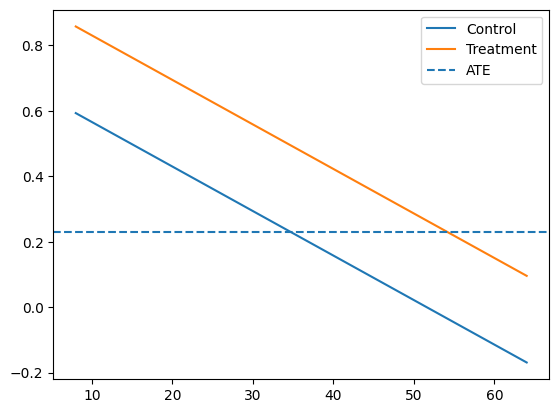

In [45]:
age_grid = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = model.predict(np.column_stack((np.zeros_like(age_grid), age_grid)))
pred_treatment = model.predict(np.column_stack((np.ones_like(age_grid), age_grid)))
ATE = heart[heart['treatment_var'] == 1]['y'].mean() - heart[heart['treatment_var'] == 0]['y'].mean()

plt.plot(age_grid, pred_control, label='Control')
plt.plot(age_grid, pred_treatment, label='Treatment')

plt.axhline(y=ATE, linestyle='--', label='ATE')

plt.legend()
plt.show()

For ages 55+, the ATE over-estimates the impact of a transplant. For ages 0-35, ATE underestimates the impact of a transplant. 

In [46]:
# 4

heart['treatment_var'] = (heart['transplant'] == 'treatment').astype(int)
heart['treatment_age'] = heart['treatment_var'] * heart['age']

X = heart[['treatment_var', 'age', 'treatment_age']]
y = heart['y']

model = LinearRegression()
model.fit(X, y)

b0 = model.intercept_
b1 = model.coef_[0]
b2 = model.coef_[1]
b3 = model.coef_[2]

print('Intercept:', b0)
print('Treatment:', b1)
print('Age:', b2)
print('Treatment and Age:', b3)

Intercept: 0.35486517529945905
Treatment: 0.9077513885685894
Age: -0.005524257506973704
Treatment and Age: -0.014590638256855276


Allowing age and transplant to interact tells us whether the effect of the transplant depends on age. The Treatment coefficient tells us that there is a high survival rate when age = 0. The Age coefficient tells us that age negatively affects the control group. The Treatment & Age coefficient tells us that transplant effect and age have a negative relationship. Altogether, this show that as age increases, survival rate decreases. 

In [47]:
# 5

from sklearn.model_selection import KFold

heart['treatment_var'] = (heart['transplant'] == 'treatment').astype(int)
heart['treatment_age'] = heart['treatment_var'] * heart['age']

y = heart['y']

X1 = heart[['treatment_var']]
X2 = heart[['treatment_var', 'age']]
X3 = heart[['treatment_var', 'age', 'treatment_age']]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

mse1 = -cross_val_score(LinearRegression(), X1, y, cv=kf, scoring='neg_mean_squared_error')
mse2 = -cross_val_score(LinearRegression(), X2, y, cv=kf, scoring='neg_mean_squared_error')
mse3 = -cross_val_score(LinearRegression(), X3, y, cv=kf, scoring='neg_mean_squared_error')

print('Model 1 (Treatment) MSE:', mse1.mean())
print('Model 2 (Treatment and Age) MSE:', mse2.mean())
print('Model 3 (Treatment, Age, and Treatment*Age) MSE:', mse3.mean())

Model 1 (Treatment) MSE: 0.19497249586192156
Model 2 (Treatment and Age) MSE: 0.1792641595495216
Model 3 (Treatment, Age, and Treatment*Age) MSE: 0.17880206762517337


Model 3, which controlled for transplant, age, and transplant*age had the lowest MSE, meaning that it had the most accurate prediction. The MSE for Model 2, which controlled for transplant and age, had a very similar MSE. This shows that Age is an important factor in predicting treatment effect.  

6.

If this model was used to prioritize transplant access, there would be concerns about bias. This model only uses transplant, age, and the interaction of both to predict survival. It does not account for confounding variables present in this scenario such as other pre-existing health conditions and severity of heart disease. Additionally, there may have been other factors besides age that impacted whether or not patients got a transplant. Therefore, this model should not be used as the sole decision-maker for prioritizing transplant access.